In [ ]:
#librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.read_csv("customer_segmentation_dataset.csv")
df.head()

,customer_id,annual_spending_usd,purchase_frequency_orders_per_year,avg_order_value_usd,days_since_last_purchase,cluster
0,CUST00001,5496.71,24.3,232.38,30,3
1,CUST00002,4765.85,23.8,278.96,23,3
2,CUST00003,4530.53,27.7,176.83,10,3
3,CUST00004,5241.96,15.4,113.75,9,3
4,CUST00005,3987.17,26.6,154.60,1,3


In [ ]:
#verificación na's
df.isna().sum()

,0
customer_id,0
annual_spending_usd,0
purchase_frequency_orders_per_year,0
avg_order_value_usd,0
days_since_last_purchase,0
cluster,0


In [ ]:
#escalamiento de los datos
X=df.drop('customer_id', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

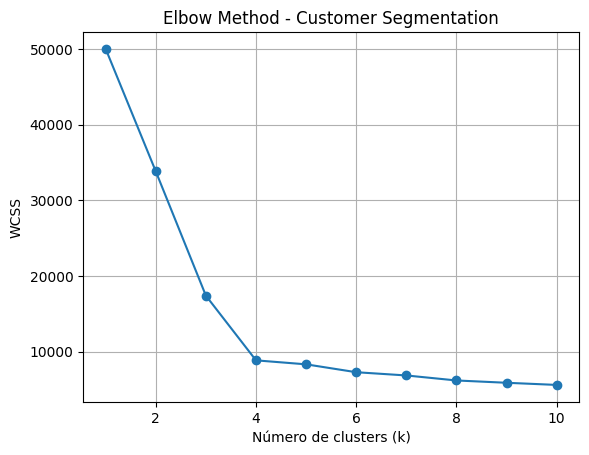

In [ ]:
#elbow method
wcss = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(K_range, wcss, marker='o')
plt.title("Elbow Method - Customer Segmentation")
plt.xlabel("Número de clusters (k)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

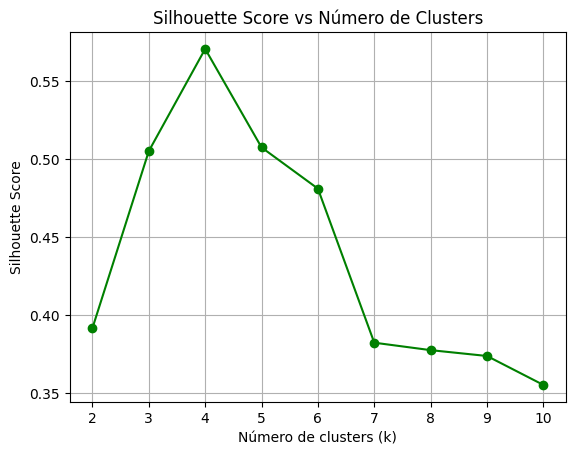

Mejor k según silhouette: 4


In [ ]:
#silhouette analysis
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.plot(range(2, 11), silhouette_scores, marker='o', color='green')
plt.title("Silhouette Score vs Número de Clusters")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

best_k = np.argmax(silhouette_scores) + 2
print(f"Mejor k según silhouette: {best_k}")


In [ ]:
kmeans_final = KMeans(n_clusters=best_k, init='k-means++', random_state=42)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

print("\nNúmero de clientes por cluster:")
print(df['Cluster'].value_counts(), "\n")


Número de clientes por cluster:
Cluster
0    3650
1    2581
2    1953
3    1816
Name: count, dtype: int64 



In [ ]:
centroids_original = scaler.inverse_transform(kmeans_final.cluster_centers_)
centroids_df = pd.DataFrame(
    centroids_original,
    columns=X.columns
)
print("Centroides:\n", centroids_df)

Centroides:
    annual_spending_usd  purchase_frequency_orders_per_year  \
0          2476.442644                           11.699233   
1           832.180922                           14.803952   
2          5059.153856                           25.109780   
3          1186.403563                            4.004185   

   avg_order_value_usd  days_since_last_purchase       cluster  
0           211.342466                 45.300274  2.000000e+00  
1            53.952425                 30.572259 -3.952394e-14  
2           198.706979                 15.634921  3.000000e+00  
3           308.521338                125.936674  1.000000e+00  
